# CS1090B / AC209B: Kalshi Prediction Markets, Mixture of Experts Pipeline

**Group 52** | Andres Blanco Prada, Gianluca Pisa, Lennard Pische, Vishwesh Venkatramani, Moritz Wassermann

**Disclaimer: PLEASE ONLY RUN THIS NOTEBOOK, as running underlying model notebooks will overwrite existing paths and duplicate files**

**Teaching staff:** You can **review this notebook as-is** (text, equations, and saved outputs) without copying anything from Drive. The submission documents the full pipeline. **Only copy or download the Drive folder if you intend to re-run cells** (training, loading parquet, checkpoints). That folder is **larger than 10 GB** (data + models + caches). Optional source: [project (Google Drive)](https://drive.google.com/drive/folders/1bwPVZxxEhNfPodRlXFBZV-RKXiuSnlkq?usp=sharing). To re-run: copy the entire **`project`** tree into your Google Drive, open this notebook from `project/notebooks/`, run the **TF setup** cell (edit `PROJECT_ROOT` if your copy is not under `MyDrive/CS1090B/project`), then run the rest (e.g. **Runtime → Run all** in Colab).

## Overview

This notebook presents the complete end-to-end pipeline for our Mixture of Experts (MoE) model for short-horizon price movement prediction on Kalshi prediction markets.

**Task.** Given a trade observation, predict whether the contract `yes_price` will move up (+1), remain flat (0), or move down (-1) over a forward window of 5, 15, 30, or 60 minutes. A "jump" is defined as the price crossing the top or bottom 12.5% of per-ticker forward returns computed on the training fold.

**Approach.** Six independently trained base models (LightGBM, LSTM, Mamba, Moirai, FT-Transformer, and Conformer-Tiny Time-Series) each output a 3-class probability vector for a given horizon. A learned gating network (a small MLP) combines these expert predictions via a weighted sum whose weights are conditioned on per-trade contextual features. This lets the model dynamically choose whichever expert is most reliable for a given market regime.

**Data.** Pre-computed base-model probability outputs, trade-level features, and engineered meta-features are stored in `moe_data.parquet` on Google Drive. See `notebooks/preprocessing_clean_m4.ipynb` (36-feature creation) and `notebooks/EDA_baseline.ipynb` (baseline modeling) for the feature engineering pipeline.

**Supporting notebooks:**
- `notebooks/EDA_baseline.ipynb`: exploratory data analysis and CNN
- `notebooks/mamba_model.ipynb`: Mamba model predictions
- `notebooks/Moirai_Model.ipynb`: Moirai model predictions
- `notebooks/CTTS_model.ipynb`: CTTS model predictions
- `notebooks/LSTM_LGBM_models.ipynb`: LightGBM and LSTM model predictions
- `notebooks/FT_transformer_model.ipynb` : FT transformer predictions
- `notebooks/combining_parquet_files.ipynb`: parquet prediction concatenation for MoE model
- `notebooks/moe_features.ipynb`: parquet feature preprocessing for MoE


## Table of contents

1. [Project folder layout (Google Drive)](#project-folder-layout-google-drive)
2. [TF setup: paths and Drive mount](#tf-setup-paths-and-drive-mount)
3. [1. Data Loading](#1-data-loading)
4. [2. Imports and Global Configuration](#2-imports-and-global-configuration)
5. [3. Model Architecture](#3-model-architecture)
6. [4. Training](#4-training)
7. [5. Evaluation on the Held-Out Test Set](#5-evaluation-on-the-held-out-test-set)
8. [6. Multi-Horizon Analysis](#6-multi-horizon-analysis)


## Project folder layout (Google Drive)

Teaching staff: **you do not need to copy this layout locally** unless you are re-running the notebook. The tree below describes what lives on Drive (**>10 GB** total). For a read-only review, the submitted notebook alone is enough.

If you do re-run: copy the shared **`project`** folder into your Google Drive. **Source folder:** [project — Google Drive](https://drive.google.com/drive/folders/1bwPVZxxEhNfPodRlXFBZV-RKXiuSnlkq?usp=sharing).

After copying, the expected layout is:

```
project/
├── notebooks/                    # Main + exploratory notebooks (run this file only for the full MoE pipeline)
│   ├── cs1090b_ms4_main_group52.ipynb   # this notebook
│   ├── EDA_baseline.ipynb
│   ├── preprocessing_cleaning.ipynb
│   ├── combining_parquet_files.ipynb
│   ├── moe_features.ipynb
│   ├── LSTM_LGBM_models.ipynb
│   ├── mamba_model.ipynb
│   ├── Moirai_Model.ipynb
│   ├── CTTS_model.ipynb
│   └── FT_transformer_model.ipynb
├── data/
│   ├── trades raw/
│   │   └── all_trades.parquet
│   ├── all_trades_features.parquet
│   ├── moe_data.parquet          # primary input for this notebook
│   ├── moirai_all_trades_logits.parquet
│   ├── mamba_all_trades_logits.parquet
│   ├── CTTS_predictions.parquet
│   ├── ftt_predictions.parquet
│   ├── stacking_predictions.parquet
│   └── models/                   # checkpoints (e.g. moe_gate_*.pt, base models, lgbm_*.txt, …)
├── moe_cache/
│   └── shared_expert_preds.pkl
└── requirements.txt             # optional; installed automatically if present at project root
```

Paths in code use **`PROJECT_ROOT`** from the next cell so nothing is tied to one Google account.


## TF setup: paths and Drive mount

**Only run the Python cell below if you are re-executing this notebook** (it expects parquet and checkpoints on Drive). For grading or reading along, you can skip this section entirely.

If you did copy the shared `project` folder into Drive, run the cell once per Colab session. If your copy is not at `MyDrive/CS1090B/project`, edit `PROJECT_ROOT` so it points at the folder that contains `data/` and `notebooks/`.


In [ ]:
# --- TF setup: paths and Drive mount (run this cell once per session) ---
# 1) Copy the whole `project` folder into YOUR Google Drive (any path is fine).
# 2) Set PROJECT_ROOT to that folder — it must be the directory that contains `data/` and `notebooks/`.

import os
import sys
import subprocess
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive", force_remount=False)

# <<< Edit this if your copy of `project` is not at this path >>>
PROJECT_ROOT = Path("/content/drive/MyDrive/CS1090B/project")

DATA_ROOT = str(PROJECT_ROOT / "data")
MODEL_DIR = os.path.join(DATA_ROOT, "models")
MOE_CACHE = os.path.join(str(PROJECT_ROOT), "moe_cache")

_data = PROJECT_ROOT / "data"
if not _data.is_dir():
    raise FileNotFoundError(
        f"Missing {_data}. Update PROJECT_ROOT to the copied project folder "
        "(the one that contains `data` and `notebooks`)."
    )
os.makedirs(MODEL_DIR, exist_ok=True)

_req = PROJECT_ROOT / "requirements.txt"
if _req.is_file():
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", str(_req)])

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:   ", DATA_ROOT)
print("MODEL_DIR:   ", MODEL_DIR)
print("MOE_CACHE:   ", MOE_CACHE)


In [ ]:
%pip install numpy pandas pyarrow torch scikit-learn matplotlib seaborn -q

In [2]:
# Paths and Drive mount are configured in the **TF setup** cell above.
assert "DATA_ROOT" in globals() and DATA_ROOT, "Run the TF setup cell first."

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Data Loading

The pre-processed dataset `moe_data.parquet` contains one row per trade with 135 columns:

- **Trade features (~40 columns):** raw trade attributes (`yes_price`, `no_price`, `count`, `taker_side`, `log_volume`) and rolling statistics computed over recent trades within the same ticker.
- **Base-model probability outputs (72 columns):** each base model's predicted 3-class probability vector (`probability_down_*`, `probability_no_jump_*`, `probability_up_*`) for each of the four prediction horizons.
- **Labels (4 columns):** `jump3_{H}m` for H in {5, 15, 30, 60}, encoding price direction as -1, 0, or +1.

The data covers January through December 2025. Paths are under `DATA_ROOT`, set in the **TF setup** cell at the top of this notebook.

In [3]:
import os
import pandas as pd

df = pd.read_parquet(os.path.join(DATA_ROOT, "moe_data.parquet"))
df.head()

,ticker,yes_price,no_price,count,taker_side,created_time,volume,log_volume,target_price_5m,signed_ret_5m,...,probability_down_5minutes_moirai,probability_no_jump_15minutes_moirai,probability_up_15minutes_moirai,probability_down_15minutes_moirai,probability_no_jump_30minutes_moirai,probability_up_30minutes_moirai,probability_down_30minutes_moirai,probability_no_jump_60minutes_moirai,probability_up_60minutes_moirai,probability_down_60minutes_moirai
0,ACPI-24-B2.5,79,21,992,yes,2025-01-06 16:02:37.618186,78368.0,11.269184,79.0,0.0,...,0.04875,0.921485,0.032028,0.046487,0.926274,0.023716,0.050010,0.929172,0.021895,0.048933
1,ACPI-24-B2.5,79,21,500,no,2025-01-07 00:47:25.410839,10500.0,9.259226,78.0,-1.0,...,0.04238,0.930946,0.029492,0.039561,0.933477,0.026275,0.040248,0.938123,0.024355,0.037523
2,ACPI-24-B2.5,77,23,15,no,2025-01-07 00:47:25.410839,345.0,5.846439,78.0,1.0,...,0.04238,0.930946,0.029492,0.039561,0.933477,0.026275,0.040248,0.938123,0.024355,0.037523
3,ACPI-24-B2.5,77,23,576,no,2025-01-07 00:47:25.410839,13248.0,9.491677,78.0,1.0,...,0.04238,0.930946,0.029492,0.039561,0.933477,0.026275,0.040248,0.938123,0.024355,0.037523
4,ACPI-24-B2.5,78,22,1768,no,2025-01-07 00:47:25.410839,38896.0,10.568672,78.0,0.0,...,0.04238,0.930946,0.029492,0.039561,0.933477,0.026275,0.040248,0.938123,0.024355,0.037523


## 2. Imports and Global Configuration

The cell below loads all required libraries and defines global constants. `HORIZON` controls which prediction window (in minutes) is used for the single-horizon training run in Sections 3 to 5; change this value and re-run all cells to reproduce results for a different horizon. Section 6 iterates over all four horizons automatically.

In [31]:
import os, math, time, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}',
      f'GPU: {torch.cuda.get_device_name(0)}' if DEVICE == 'cuda' else '')

HORIZON = 5        # ← change to 5, 15, 30, or 60 and re-run all cells
N_EXPERTS = 6
N_CLASSES = 3
EXPERT_NAMES = ['lgbm', 'lstm', 'mamba', 'moirai', 'ftt', 'ctts']

LABEL_MAP = {-1.0: 0, 0.0: 1, 1.0: 2}


def expert_prob_cols(model, horizon):
    """Return [down, no_jump, up] column names for a given model + horizon."""
    if model in ['lgbm', 'lstm', 'mamba', 'moirai']:
        s = f'{horizon}minutes_{model}'
    else:  # ftt, ctts
        s = f'{horizon}m_{model}'
    return [f'probability_down_{s}',
            f'probability_no_jump_{s}',
            f'probability_up_{s}']


def build_feature_list(df, horizon):
    """Compute the list of feature columns the GATE sees for this horizon."""
    leak = {'ticker', 'created_time', 'split', 'count',
            'volume', 'no_price', 'taker_side'}
    for h in [5, 15, 30, 60]:
        leak.update([f'target_price_{h}m', f'signed_ret_{h}m',
                     f'abs_ret_{h}m', f'jump3_{h}m'])
        if h != horizon:
            for m in EXPERT_NAMES:
                leak.update(expert_prob_cols(m, h))
            # Also drop OTHER horizons' meta-features
            leak.update([c for c in df.columns
                         if c.endswith(f'_{h}m') and (
                             c.startswith('rolling_') or
                             c.startswith('has_') or
                             c.startswith('agreement_'))])

    return [c for c in df.columns if c not in leak]

Device: cuda GPU: NVIDIA A100-SXM4-80GB


## 3. Model Architecture

The MoE layer has two components: a `MoEDataset` that packages per-trade tensors for PyTorch training, and a `MoEGate` MLP that learns to weight the six expert predictions.

### 3.1 Dataset Class

`MoEDataset` extracts three tensors per trade:
1. **Gate features** `(F,)`: standardized contextual features the gating network uses to decide which experts to trust.
2. **Expert probabilities** `(6, 3)`: the 3-class softmax outputs from each of the six base models.
3. **Expert mask** `(6,)`: a binary indicator set to 0 for any expert whose output is missing (NaN) for this horizon or trade. Missing experts receive a uniform `[1/3, 1/3, 1/3]` placeholder; the gate ignores them via a large negative pre-softmax constant.

In [32]:
class MoEDataset(Dataset):
    """Yields (gate_features, expert_probs, expert_mask, label)."""
    def __init__(self, df, horizon, gate_feat_cols, gate_mean, gate_std, split=None):
        if split is not None:
            df = df[df['split'] == split].reset_index(drop=True)
        self.n = len(df)

        # ---- Gate features ----

        # Special-case rolling_acc_* NaN fill: use random-guess baseline (1/3)
        # instead of letting train-fold mean leak through
        df_copy = df[gate_feat_cols].copy()
        rolling_acc_cols = [c for c in gate_feat_cols if c.startswith('rolling_acc_')]
        if rolling_acc_cols:
            df_copy[rolling_acc_cols] = df_copy[rolling_acc_cols].fillna(1.0 / 3.0)

        gate_feats = df_copy.values.astype(np.float32)
        # Standardize using train-fold stats
        gate_feats = (gate_feats - gate_mean) / gate_std
        # Remaining NaN/inf → 0 (= train-fold mean post-standardization)
        gate_feats = np.nan_to_num(gate_feats, nan=0.0, posinf=0.0, neginf=0.0)
        self.gate_feats = gate_feats
        del df_copy

        # ---- Expert probabilities and availability mask ----
        expert_probs = np.zeros((self.n, N_EXPERTS, N_CLASSES), dtype=np.float32)
        expert_mask = np.zeros((self.n, N_EXPERTS), dtype=np.float32)
        for e_idx, m in enumerate(EXPERT_NAMES):
            cols = expert_prob_cols(m, horizon)
            vals = df[cols].values.astype(np.float32)
            valid = np.isfinite(vals).all(axis=1)
            expert_probs[valid, e_idx, :] = vals[valid]
            # Uniform [1/3, 1/3, 1/3] for missing — gate ignores via mask
            expert_probs[~valid, e_idx, :] = 1.0 / N_CLASSES
            expert_mask[:, e_idx] = valid.astype(np.float32)
        self.expert_probs = expert_probs
        self.expert_mask = expert_mask

        # ---- Labels ----
        labels = df[f'jump3_{horizon}m'].map(LABEL_MAP).astype(np.int64).values
        self.labels = labels

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        return (torch.from_numpy(self.gate_feats[idx]),
                torch.from_numpy(self.expert_probs[idx]),
                torch.from_numpy(self.expert_mask[idx]),
                int(self.labels[idx]))

### 3.2 Gating Network

`MoEGate` is a three-layer MLP with LayerNorm and GELU activations. It reads the gate features, produces a 6-dimensional logit vector (one per expert), and applies a masked softmax so unavailable experts receive zero weight. The final class probabilities are a convex combination of the expert probability vectors, weighted by the gate output.

In [33]:
class MoEGate(nn.Module):
    """Tabular MoE gating network.
    Takes (gate_features, expert_probs, expert_mask), produces class probabilities."""
    def __init__(self, n_features, hidden_dims=(192, 96, 48),
                 n_experts=6, dropout=0.3):
        super().__init__()
        self.n_experts = n_experts

        layers = []
        prev = n_features
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.LayerNorm(h),
                       nn.GELU(), nn.Dropout(dropout)]
            prev = h
        self.backbone = nn.Sequential(*layers)
        self.gate_head = nn.Linear(prev, n_experts)

    def forward(self, gate_feats, expert_probs, expert_mask):
        h = self.backbone(gate_feats)
        gate_logits = self.gate_head(h)
        # Mask out unavailable experts before softmax
        gate_logits = gate_logits.masked_fill(expert_mask == 0, -1e9)
        gate_weights = F.softmax(gate_logits, dim=-1)
        # Weighted combination of expert probabilities
        final_probs = (gate_weights.unsqueeze(-1) * expert_probs).sum(dim=1)
        final_probs = final_probs.clamp(min=1e-7, max=1 - 1e-7)
        return final_probs, gate_weights

## 4. Training

### 4.1 Feature Selection and Data Splits

`build_feature_list` reduces the 135-column dataframe to the gate input features for a given horizon. It removes direct look-ahead columns (target prices, signed returns, absolute returns, jump labels), probability columns from other horizons to prevent cross-horizon leakage, and ticker/timestamp identifiers.

We use a chronological split:
- **Fit set (90% of train):** trades before approximately October 29, 2025. Used for gradient updates and normalization statistics.
- **Validation set (10% of train):** trades between October 29 and November 6, 2025. Used for early stopping only.
- **Test set (20% of all data):** trades from November 6, 2025 onward. Held out until final evaluation.

Class weights are computed from the fit-set label distribution to offset the heavy imbalance toward the "flat" class.

In [34]:
print(f'=== Training MoE gate for horizon = {HORIZON}m ===')

GATE_FEAT_COLS = build_feature_list(df, HORIZON)
print(f'Gate input features: {len(GATE_FEAT_COLS)}')

# Show breakdown
n_base  = sum(1 for c in GATE_FEAT_COLS if not c.startswith(('rolling_', 'has_',
                                                              'agreement_', 'probability_')))
n_probs = sum(1 for c in GATE_FEAT_COLS if c.startswith('probability_'))
n_meta  = len(GATE_FEAT_COLS) - n_base - n_probs
print(f'  base trade features: {n_base}')
print(f'  expert probabilities: {n_probs}')
print(f'  engineered meta features: {n_meta}')

# Define fit/val/test split using the ORIGINAL 80% timestamp
# (anchored on base-model split, not on filtered df)
TEST_CUT = pd.Timestamp('2025-11-06 03:58:08.028990', tz='UTC')

# Strip tz to match df['created_time'] which is tz-naive after normalize
if df['created_time'].dt.tz is None:
    TEST_CUT = TEST_CUT.tz_localize(None)

train_mask = df['created_time'] < TEST_CUT
val_cut = df.loc[train_mask, 'created_time'].quantile(0.9)
fit_mask = train_mask & (df['created_time'] < val_cut)

print(f'Test cut (from base models): {TEST_CUT}')
print(f'Val cut (within train fold):  {val_cut}')
print(f'  train rows:    {train_mask.sum():>12,}')
print(f'  test rows:     {(~train_mask).sum():>12,}')
print(f'  → fit (90%):   {fit_mask.sum():>12,}')
print(f'  → val (10%):   {(train_mask & ~fit_mask).sum():>12,}')
# Z-score stats from FIT fold only — handle rolling_acc separately
df_for_stats = df.loc[fit_mask, GATE_FEAT_COLS].copy()
rolling_acc_cols = [c for c in GATE_FEAT_COLS if c.startswith('rolling_acc_')]
if rolling_acc_cols:
    df_for_stats[rolling_acc_cols] = df_for_stats[rolling_acc_cols].fillna(1.0 / 3.0)

gate_mean = df_for_stats.mean().values.astype(np.float32)
gate_std = df_for_stats.std().replace(0, 1.0).values.astype(np.float32)
del df_for_stats
gc.collect()

# Build datasets
print('Building datasets...')
fit_ds  = MoEDataset(df[fit_mask],                    HORIZON, GATE_FEAT_COLS, gate_mean, gate_std)
val_ds  = MoEDataset(df[train_mask & ~fit_mask],      HORIZON, GATE_FEAT_COLS, gate_mean, gate_std)
test_ds = MoEDataset(df[~train_mask],                 HORIZON, GATE_FEAT_COLS, gate_mean, gate_std)
print(f'  fit: {len(fit_ds):,}  val: {len(val_ds):,}  test: {len(test_ds):,}')

# Class weights from fit fold
counts = np.bincount(fit_ds.labels, minlength=3).astype(np.float64)
cls_w = counts.sum() / (3 * np.maximum(counts, 1))
class_weights = torch.tensor(cls_w, dtype=torch.float32, device=DEVICE)
print(f'  class weights: {cls_w.round(3)}')

# Training hyperparameters
BATCH_SIZE = 4096
LR = 1e-3
MAX_EPOCHS = 30
PATIENCE = 1
WARMUP_STEPS = 500
ENTROPY_LAMBDA = 0.01

# Instantiate model
model = MoEGate(
    n_features=len(GATE_FEAT_COLS),
    hidden_dims=(192, 96, 48),
    n_experts=N_EXPERTS,
    dropout=0.3,
).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'  trainable params: {n_params:,}')

=== Training MoE gate for horizon = 5m ===
Gate input features: 58
  base trade features: 40
  expert probabilities: 18
  engineered meta features: 0
Test cut (from base models): 2025-11-06 03:58:08.028990
Val cut (within train fold):  2025-10-29 02:16:46.968652800
  train rows:      34,956,173
  test rows:        8,593,950
  → fit (90%):     31,460,555
  → val (10%):      3,495,618
Building datasets...
  fit: 31,460,555  val: 3,495,618  test: 8,593,950
  class weights: [3.352 0.416 3.36 ]
  trainable params: 35,478


### 4.2 Training Loop

We use AdamW with a cosine learning-rate schedule and a 500-step linear warmup. The objective combines a class-weighted negative log-likelihood with a small entropy bonus on the gate weights (coefficient 0.01). The entropy term prevents the gate from collapsing its weight onto a single expert. Early stopping halts training when validation NLL shows no improvement for one epoch.

In [35]:
fit_loader = DataLoader(fit_ds, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE * 2, shuffle=False,
                        num_workers=2, pin_memory=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = MAX_EPOCHS * len(fit_loader)

def lr_lambda(step):
    if step < WARMUP_STEPS:
        return step / max(1, WARMUP_STEPS)
    p = (step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
    return 0.5 * (1 + math.cos(math.pi * p))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def compute_loss(final_probs, gate_weights, labels):
    log_probs = torch.log(final_probs)
    nll = F.nll_loss(log_probs, labels, weight=class_weights)
    entropy = -(gate_weights * torch.log(gate_weights.clamp(min=1e-9))).sum(-1).mean()
    return nll - ENTROPY_LAMBDA * entropy, nll, entropy


@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_nll, total_n = 0.0, 0
    for xb, eb, mb, yb in loader:
        xb, eb, mb, yb = (xb.to(DEVICE), eb.to(DEVICE),
                          mb.to(DEVICE), yb.to(DEVICE))
        final_probs, gate_w = model(xb, eb, mb)
        log_probs = torch.log(final_probs)
        nll = F.nll_loss(log_probs, yb, weight=class_weights, reduction='sum')
        total_nll += nll.item()
        total_n += yb.size(0)
    return total_nll / max(1, total_n)


# Training loop with early stopping
best_val = float('inf')
best_epoch = -1
patience_left = PATIENCE
os.makedirs(MODEL_DIR, exist_ok=True)
ckpt_path = os.path.join(MODEL_DIR, f'moe_gate_{HORIZON}m.pt')

for epoch in range(MAX_EPOCHS):
    model.train()
    epoch_loss, n_batches = 0.0, 0
    t0 = time.time()
    for xb, eb, mb, yb in fit_loader:
        xb, eb, mb, yb = (xb.to(DEVICE, non_blocking=True),
                           eb.to(DEVICE, non_blocking=True),
                           mb.to(DEVICE, non_blocking=True),
                           yb.to(DEVICE, non_blocking=True))
        final_probs, gate_w = model(xb, eb, mb)
        loss, nll, ent = compute_loss(final_probs, gate_w, yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()
        n_batches += 1

    train_avg = epoch_loss / n_batches
    val_loss = evaluate(val_loader)
    print(f'epoch {epoch+1:>2}: train_loss={train_avg:.4f}  val_nll={val_loss:.4f}  '
          f'time={time.time()-t0:.1f}s', end='')

    if val_loss < best_val:
        best_val = val_loss
        best_epoch = epoch + 1
        patience_left = PATIENCE
        torch.save({
            'model_state_dict': model.state_dict(),
            'gate_feat_cols': GATE_FEAT_COLS,
            'gate_mean': gate_mean,
            'gate_std': gate_std,
            'horizon': HORIZON,
            'best_val_nll': best_val,
            'best_epoch': best_epoch,
        }, ckpt_path)
        print('  ✓ saved')
    else:
        patience_left -= 1
        print(f'  (patience {patience_left}/{PATIENCE})')
        if patience_left == 0:
            print(f'\nEarly stopping at epoch {epoch+1}. '
                  f'Best val_nll={best_val:.4f} at epoch {best_epoch}.')
            break

ckpt = torch.load(ckpt_path, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'\nReloaded best (epoch {ckpt["best_epoch"]}, val_nll={ckpt["best_val_nll"]:.4f})')

epoch  1: train_loss=0.4881  val_nll=1.0138  time=316.5s  ✓ saved
epoch  2: train_loss=0.4804  val_nll=1.0199  time=312.6s  (patience 0/1)

Early stopping at epoch 2. Best val_nll=1.0138 at epoch 1.

Reloaded best (epoch 1, val_nll=1.0138)


## 5. Evaluation on the Held-Out Test Set

We evaluate the trained 5-minute model on the held-out 20% test fold using balanced accuracy (to correct for class imbalance) and macro-averaged F1. We also inspect the mean gate weight assigned to each expert to understand which base models the gating network relies on most.

In [36]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              balanced_accuracy_score, f1_score)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE * 2, shuffle=False,
                          num_workers=2, pin_memory=True)

model.eval()
all_final, all_gate, all_y = [], [], []
with torch.no_grad():
    for xb, eb, mb, yb in test_loader:
        xb, eb, mb = xb.to(DEVICE), eb.to(DEVICE), mb.to(DEVICE)
        final_probs, gate_w = model(xb, eb, mb)
        all_final.append(final_probs.cpu().numpy())
        all_gate.append(gate_w.cpu().numpy())
        all_y.append(yb.numpy())

final_probs = np.concatenate(all_final)
gate_weights = np.concatenate(all_gate)
y_test = np.concatenate(all_y)
preds = final_probs.argmax(axis=1)

print(f'=== Horizon = {HORIZON}m, test set ===')
print(f'balanced acc: {balanced_accuracy_score(y_test, preds):.4f}')
print(f'macro f1    : {f1_score(y_test, preds, average="macro"):.4f}')
print(classification_report(y_test, preds,
                            target_names=['down (-1)', 'no jump (0)', 'up (+1)'],
                            digits=4))
print('Confusion matrix:')
print(confusion_matrix(y_test, preds))

print(f'\nMean gate weight per expert (across test set):')
for e_idx, name in enumerate(EXPERT_NAMES):
    print(f'  {name:<10}: {gate_weights[:, e_idx].mean():.4f}')

=== Horizon = 5m, test set ===
balanced acc: 0.4950
macro f1    : 0.4731
              precision    recall  f1-score   support

   down (-1)     0.2618    0.3519    0.3003   1013979
 no jump (0)     0.8767    0.7744    0.8224   6578060
     up (+1)     0.2530    0.3587    0.2967   1001911

    accuracy                         0.6761   8593950
   macro avg     0.4638    0.4950    0.4731   8593950
weighted avg     0.7314    0.6761    0.6995   8593950

Confusion matrix:
[[ 356845  363470  293664]
 [ 716417 5094002  767641]
 [ 289696  352824  359391]]

Mean gate weight per expert (across test set):
  lgbm      : 0.5030
  lstm      : 0.0630
  mamba     : 0.0704
  moirai    : 0.0148
  ftt       : 0.0749
  ctts      : 0.2738


### Expert Gate Weight Dynamics

The plot below shows how the average gate weight per expert evolves over the test period. Trades are aggregated into hourly bins and smoothed with a 6-hour rolling window to reveal temporal trends without trade-level noise.

resampled to 471 hourly points


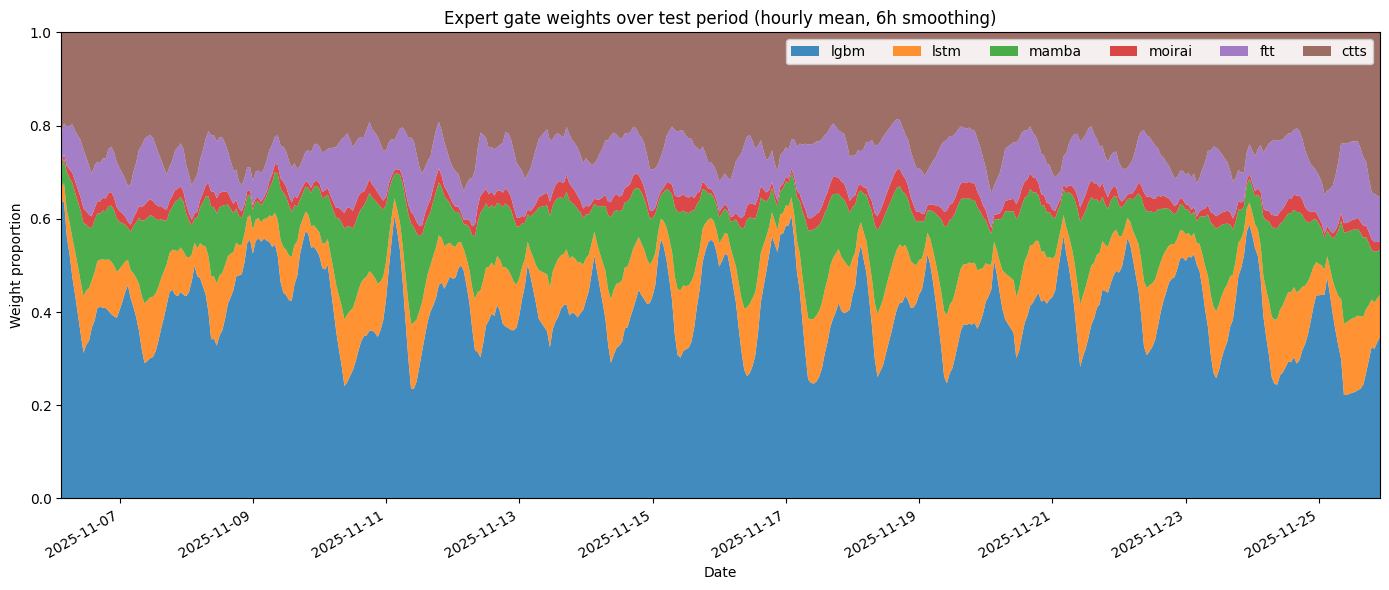

In [37]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# ---- Pull test timestamps aligned with gate_weights ----
TEST_CUT = pd.Timestamp('2025-11-06 03:58:08.028990', tz='UTC')
if df['created_time'].dt.tz is None:
    TEST_CUT = TEST_CUT.tz_localize(None)

test_times = (df.loc[df['created_time'] >= TEST_CUT, 'created_time']
                .reset_index(drop=True))

assert len(test_times) == len(gate_weights), \
    f'length mismatch: {len(test_times)} vs {len(gate_weights)}'

# ---- Build dataframe indexed by time ----
df_weights = pd.DataFrame(gate_weights, columns=EXPERT_NAMES)
df_weights['time'] = test_times.values

# ---- Sort by time and resample to a regular hourly grid ----
# This is the key step: average all trades within each hour to get one weight
# per expert per hour, instead of interleaved across tickers.
df_weights = df_weights.sort_values('time').set_index('time')
df_hourly = df_weights.resample('1h').mean().dropna()

print(f'resampled to {len(df_hourly):,} hourly points')

# Optional: light smoothing on top of the hourly bins
df_smooth = df_hourly.rolling(6, min_periods=1, center=True).mean()  # ~6h window

# ---- Plot ----
fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(df_smooth.index,
             [df_smooth[name].values for name in EXPERT_NAMES],
             labels=EXPERT_NAMES, alpha=0.85)

ax.set_title('Expert gate weights over test period (hourly mean, 6h smoothing)')
ax.set_xlabel('Date')
ax.set_ylabel('Weight proportion')
ax.set_ylim(0, 1)
ax.margins(x=0, y=0)
ax.legend(loc='upper right', ncol=len(EXPERT_NAMES), framealpha=0.9)
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 6. Multi-Horizon Analysis

The cells in this section load the saved checkpoints for all four prediction horizons (5, 15, 30, and 60 minutes), run inference on the test set for each, and produce three diagnostic visualizations:

1. **Permutation feature importance:** drop in balanced accuracy when each gate feature is randomly shuffled, averaged over two repetitions on a 200k-row subsample.
2. **Confusion matrices:** row-normalized confusion matrices for each horizon, showing where the model makes its most common errors.
3. **Gate weight distribution:** mean gate weight per expert across the test set, revealing how the gating strategy shifts with the prediction horizon.

### 6.1 Permutation Importance Utility

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score


@torch.no_grad()
def permutation_importance_moe(model, dataset, gate_feat_cols,
                                 n_repeats=2, sample_size=200_000,
                                 device='cuda'):
    """Per-feature permutation importance for the MoE gate."""
    n = len(dataset)
    rng = np.random.default_rng(0)
    idx = rng.choice(n, size=min(sample_size, n), replace=False)
    idx.sort()

    # Materialize subset
    print(f'Materializing {len(idx):,} samples...')
    X = np.stack([dataset.gate_feats[i] for i in idx])      # [N, F]
    E = np.stack([dataset.expert_probs[i] for i in idx])    # [N, E, C]
    M = np.stack([dataset.expert_mask[i] for i in idx])     # [N, E]
    y = np.array([dataset.labels[i] for i in idx])          # [N]
    print(f'X={X.shape}, E={E.shape}, M={M.shape}, y={y.shape}')

    def score(X_arr):
        model.eval()
        preds = []
        for s in range(0, len(X_arr), 8192):
            xb = torch.from_numpy(X_arr[s:s+8192]).to(device)
            eb = torch.from_numpy(E[s:s+8192]).to(device)
            mb = torch.from_numpy(M[s:s+8192]).to(device)
            final_probs, _ = model(xb, eb, mb)
            preds.append(final_probs.argmax(-1).cpu().numpy())
        return balanced_accuracy_score(y, np.concatenate(preds))

    baseline = score(X)
    print(f'baseline balanced acc: {baseline:.4f}')

    importances = {}
    for f_idx, fname in enumerate(gate_feat_cols):
        drops = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            flat = X_perm[:, f_idx].copy()
            rng.shuffle(flat)
            X_perm[:, f_idx] = flat
            drops.append(baseline - score(X_perm))
        importances[fname] = (np.mean(drops), np.std(drops))

    return importances, baseline


def plot_importance_grid(imp_per_horizon, baseline_per_horizon, top_n=25):
    """4-panel feature importance plot matching the report style."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 16))
    axes = axes.flatten()

    for ax, h in zip(axes, [5, 15, 30, 60]):
        imp = imp_per_horizon[h]
        base = baseline_per_horizon[h]
        series = pd.Series({k: v[0] for k, v in imp.items()}).sort_values()
        series.tail(top_n).plot.barh(ax=ax, color='#1f77b4')
        ax.set_title(f'MoE permutation importance – horizon {h}m '
                      f'(baseline bal acc = {base:.4f})', fontsize=11)
        ax.set_xlabel('Δ balanced accuracy (higher = more important)')
        ax.grid(alpha=0.3, axis='x')
        ax.axvline(0, color='black', linewidth=0.5)

    plt.tight_layout()
    plt.show()

### 6.2 Visualization Utilities

The two helper functions below produce the 4-panel confusion-matrix grid and the 4-panel gate-weight bar chart used in our report. They operate on the `results_eval` and `gate_weights_per_horizon` dictionaries populated by the evaluation loop in Section 6.3.

In [13]:
import seaborn as sns
from sklearn.metrics import (confusion_matrix, accuracy_score,
                              precision_recall_fscore_support)


def plot_confusion_grid(results_eval, horizons=[5, 15, 30, 60]):
    """4-panel confusion-matrix figure in the report's house style."""
    class_names = ['down', 'flat', 'up']
    fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))

    for ax, h in zip(axes, horizons):
        y, pred = results_eval[h]['y'], results_eval[h]['pred']
        acc = accuracy_score(y, pred)
        cm = confusion_matrix(y, pred, labels=[0, 1, 2])
        cm_norm = cm / cm.sum(axis=1, keepdims=True)

        sns.heatmap(cm_norm, annot=False, cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    cbar=False, ax=ax, square=True, vmin=0, vmax=1)

        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                color = 'white' if cm_norm[i, j] > 0.5 else 'black'
                ax.text(j + 0.5, i + 0.42, f'{cm_norm[i, j]:.2f}',
                        ha='center', va='center',
                        fontsize=18, fontweight='bold', color=color)
                ax.text(j + 0.5, i + 0.70, f'{cm[i, j]:,}',
                        ha='center', va='center',
                        fontsize=9, color=color, alpha=0.85)

        ax.set_title(f'{h}m  (acc {acc:.3f})', fontsize=12)
        ax.set_xlabel('predicted')
        ax.set_ylabel('true')

    plt.tight_layout()
    plt.show()


def plot_gate_weights_grid(gate_weights_per_horizon, horizons=[5, 15, 30, 60]):
    """4-panel bar chart of mean gate weight per expert per horizon."""
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    colors = plt.cm.tab10(np.linspace(0, 1, len(EXPERT_NAMES)))

    for ax, h in zip(axes, horizons):
        gw = gate_weights_per_horizon[h]
        means = gw.mean(axis=0)
        stds  = gw.std(axis=0)
        ax.bar(range(len(EXPERT_NAMES)), means, yerr=stds,
               color=colors, alpha=0.85, capsize=4)
        ax.set_xticks(range(len(EXPERT_NAMES)))
        ax.set_xticklabels(EXPERT_NAMES, rotation=30)
        ax.set_ylim(0, max(0.5, means.max() * 1.3))
        ax.axhline(1 / len(EXPERT_NAMES), color='gray', linestyle='--',
                    linewidth=0.8, alpha=0.5, label='uniform')
        ax.set_title(f'{h}m gate weights', fontsize=12)
        ax.set_ylabel('mean gate weight')
        ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

### 6.3 Evaluating All Four Horizons

The loop below iterates over all four prediction horizons. For each horizon it loads the saved checkpoint, builds the test dataset, runs inference, computes permutation importance on a 200k-row subsample, and stores the results. The three visualization functions are called once the loop completes.


Horizon = 5m
Running inference...
Computing permutation importance (this takes a few minutes)...
Materializing 200,000 samples...
X=(200000, 58), E=(200000, 6, 3), M=(200000, 6), y=(200000,)
baseline balanced acc: 0.4947

Horizon = 15m
Running inference...
Computing permutation importance (this takes a few minutes)...
Materializing 200,000 samples...
X=(200000, 58), E=(200000, 6, 3), M=(200000, 6), y=(200000,)
baseline balanced acc: 0.5121

Horizon = 30m
Running inference...
Computing permutation importance (this takes a few minutes)...
Materializing 200,000 samples...
X=(200000, 58), E=(200000, 6, 3), M=(200000, 6), y=(200000,)
baseline balanced acc: 0.5397

Horizon = 60m
Running inference...
Computing permutation importance (this takes a few minutes)...
Materializing 200,000 samples...
X=(200000, 58), E=(200000, 6, 3), M=(200000, 6), y=(200000,)
baseline balanced acc: 0.5479

Plotting feature importance...


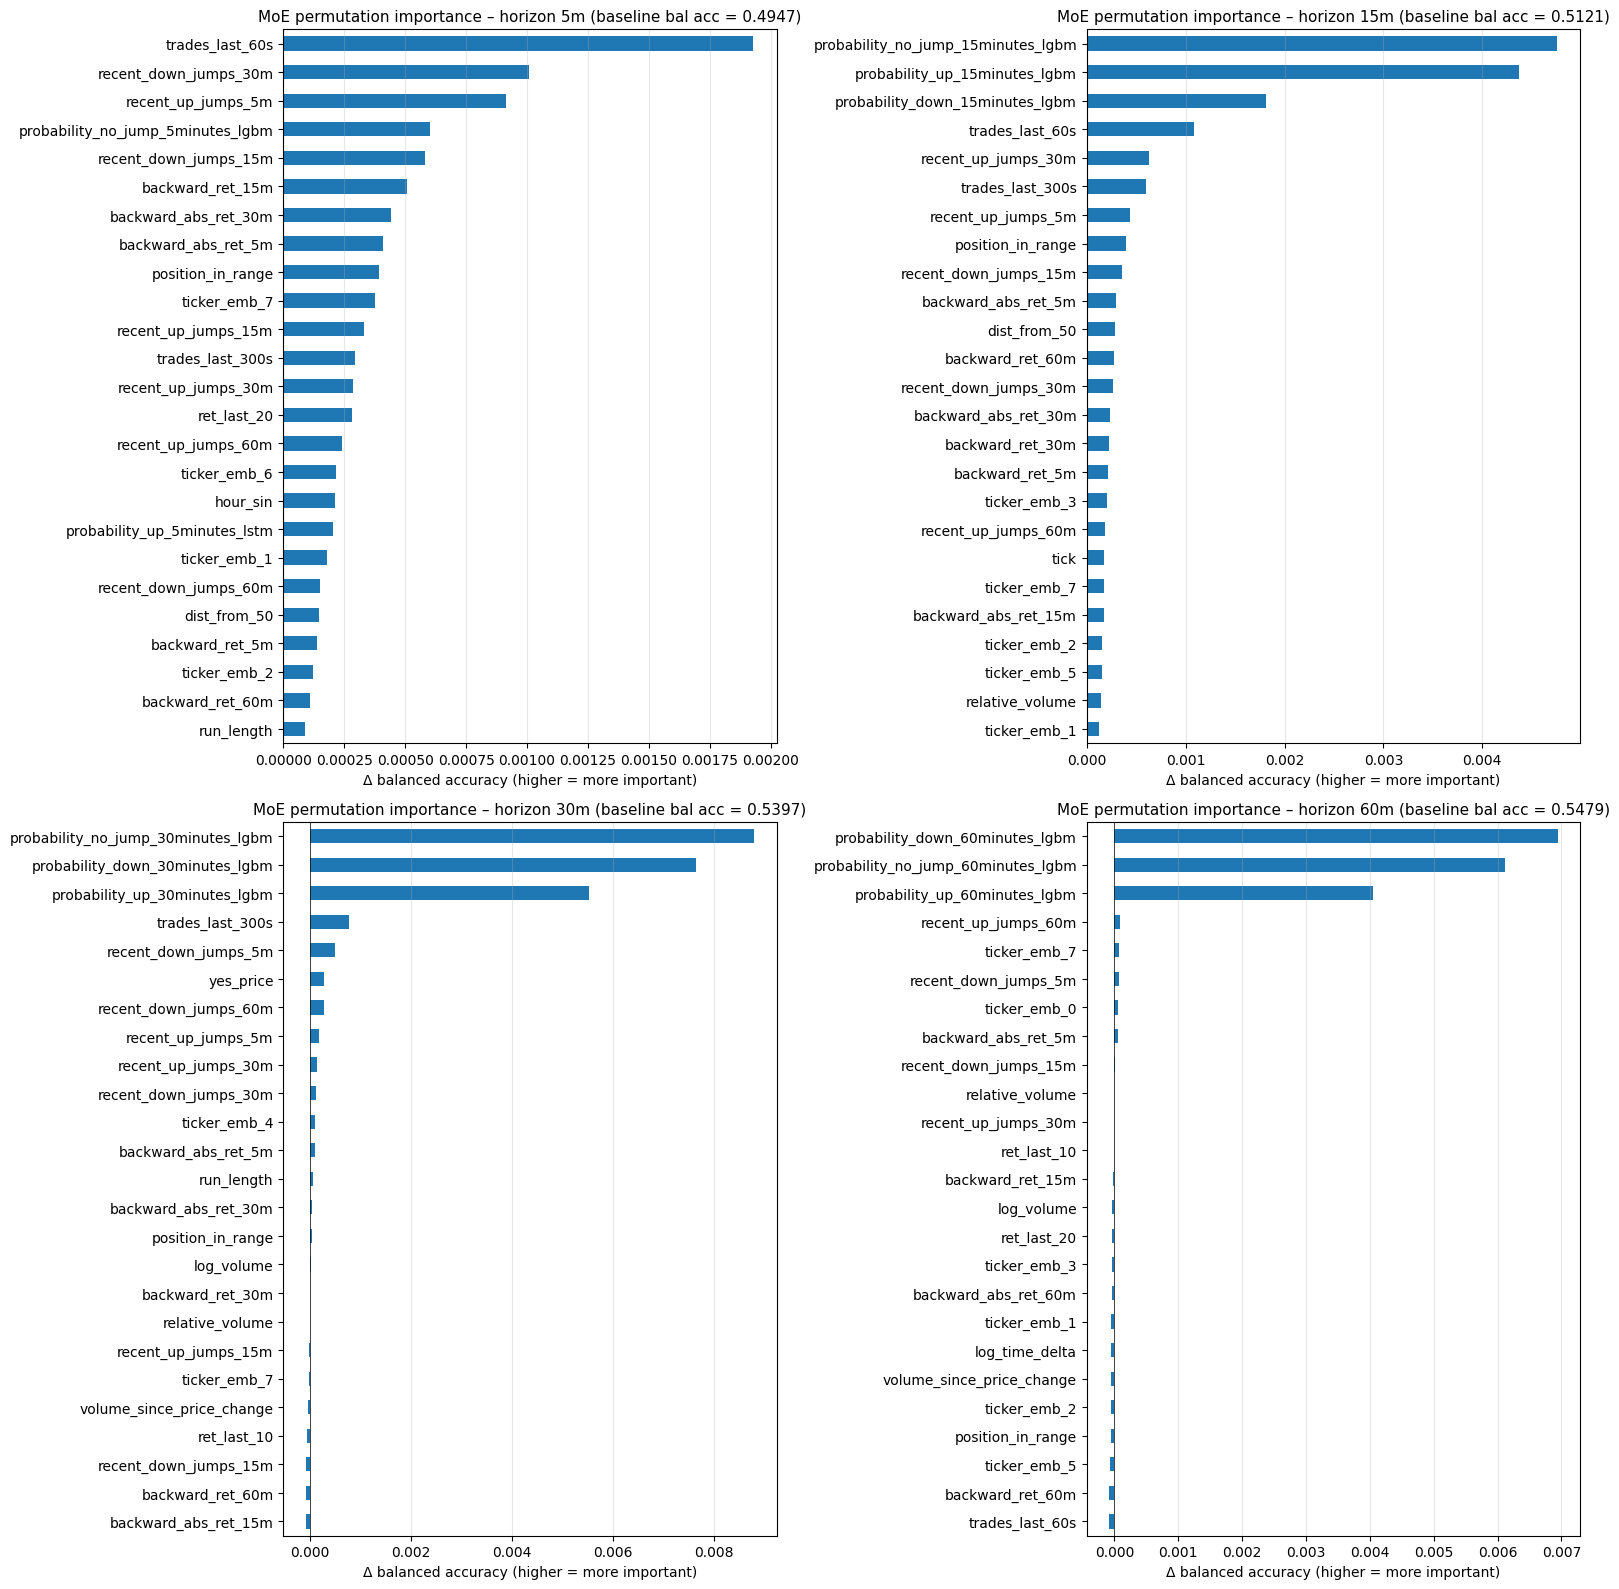


Plotting confusion matrices...


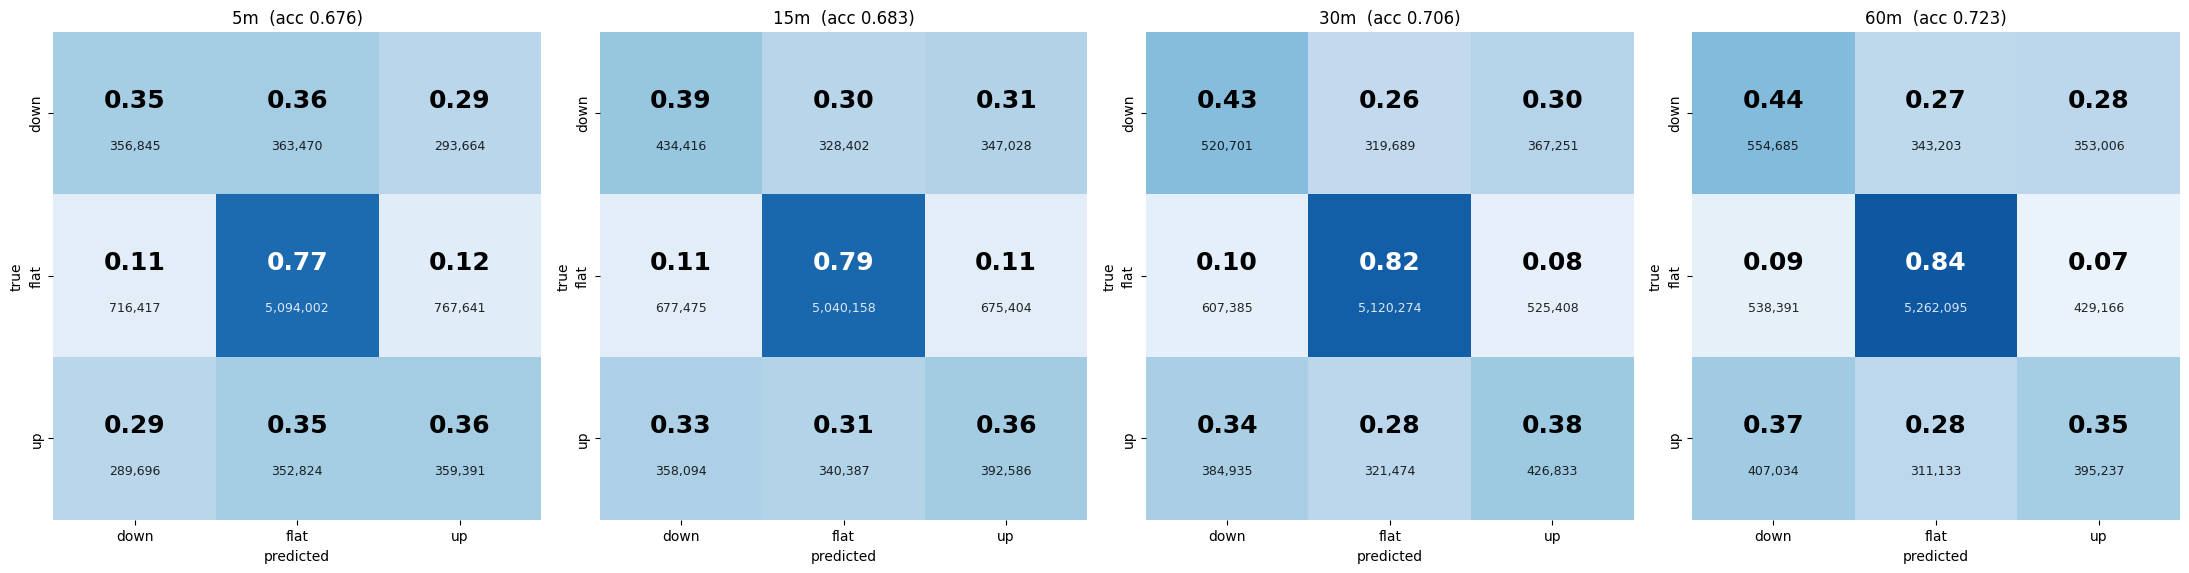


Plotting gate weights...


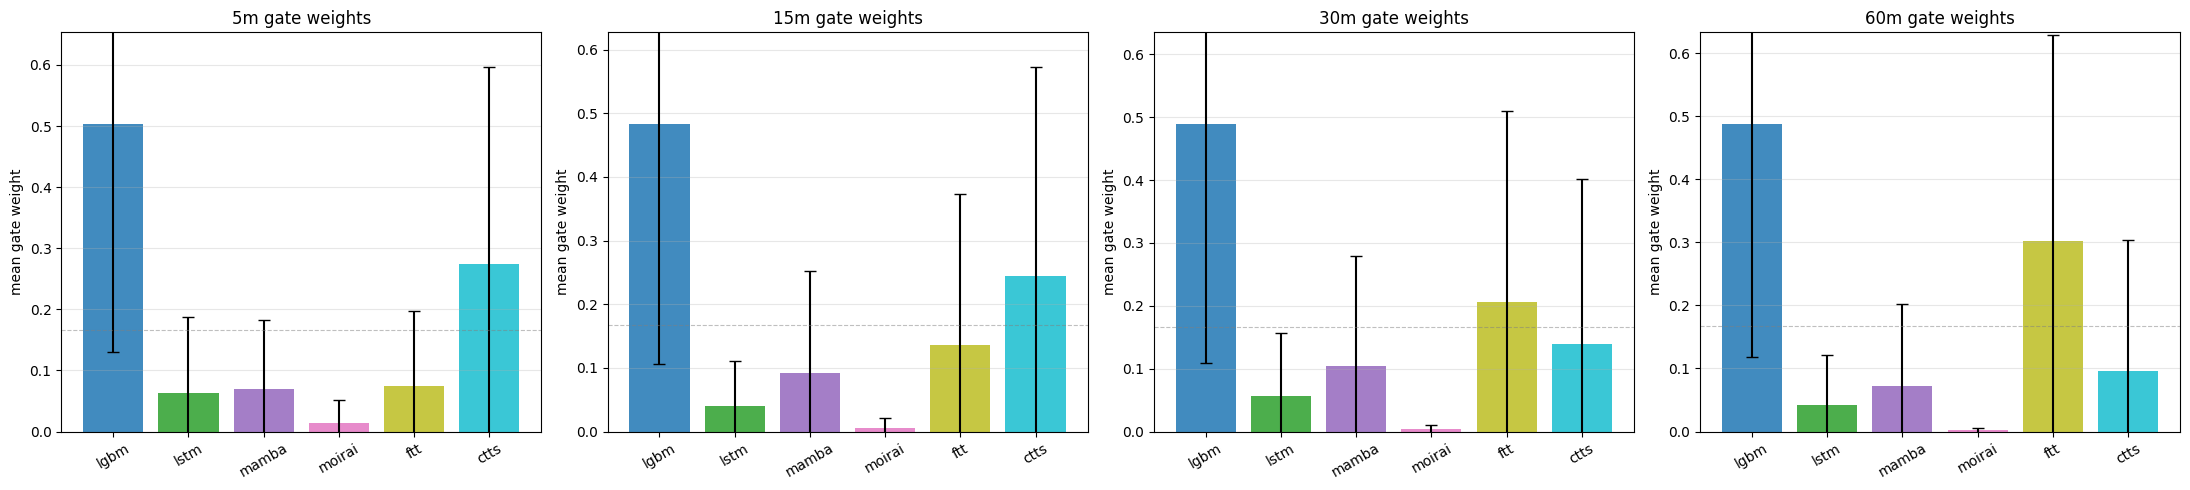

In [38]:
imp_per_horizon = {}
baseline_per_horizon = {}
results_eval = {}
gate_weights_per_horizon = {}

# Reuse the same test cut as during training
TEST_CUT = pd.Timestamp('2025-11-06 03:58:08.028990', tz='UTC')
if df['created_time'].dt.tz is None:
    TEST_CUT = TEST_CUT.tz_localize(None)

for HORIZON in [5, 15, 30, 60]:
    print(f'\n{"="*60}')
    print(f'Horizon = {HORIZON}m')
    print(f'{"="*60}')

    # Reload trained checkpoint
    ckpt_path = os.path.join(MODEL_DIR, f'moe_gate_{HORIZON}m.pt')
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)

    GATE_FEAT_COLS = ckpt['gate_feat_cols']
    gate_mean = ckpt['gate_mean']
    gate_std  = ckpt['gate_std']

    model = MoEGate(
        n_features=len(GATE_FEAT_COLS),
        hidden_dims=(192, 96, 48),
        n_experts=N_EXPERTS,
        dropout=0.3,
    ).to(DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    # Rebuild test set
    test_df = df[df['created_time'] >= TEST_CUT]
    test_ds = MoEDataset(test_df, HORIZON, GATE_FEAT_COLS, gate_mean, gate_std)
    test_loader = DataLoader(test_ds, batch_size=8192, shuffle=False,
                              num_workers=2, pin_memory=True)

    # ---- 1. Test-set predictions and gate weights ----
    print('Running inference...')
    all_final, all_gate, all_y = [], [], []
    with torch.no_grad():
        for xb, eb, mb, yb in test_loader:
            xb, eb, mb = xb.to(DEVICE), eb.to(DEVICE), mb.to(DEVICE)
            final_probs, gate_w = model(xb, eb, mb)
            all_final.append(final_probs.cpu().numpy())
            all_gate.append(gate_w.cpu().numpy())
            all_y.append(yb.numpy())

    final_probs = np.concatenate(all_final)
    gate_weights = np.concatenate(all_gate)
    y_test = np.concatenate(all_y)
    preds = final_probs.argmax(axis=1)

    results_eval[HORIZON] = {'y': y_test, 'pred': preds, 'proba': final_probs}
    gate_weights_per_horizon[HORIZON] = gate_weights

    # ---- 2. Permutation importance ----
    print('Computing permutation importance (this takes a few minutes)...')
    imp, base = permutation_importance_moe(
        model, test_ds, GATE_FEAT_COLS,
        n_repeats=2, sample_size=200_000, device=DEVICE,
    )
    imp_per_horizon[HORIZON] = imp
    baseline_per_horizon[HORIZON] = base

    # Free memory before next horizon
    del model, test_ds, test_loader, final_probs, gate_weights, y_test, preds
    gc.collect()
    torch.cuda.empty_cache()


# ---- Plot everything ----
print('\nPlotting feature importance...')
plot_importance_grid(imp_per_horizon, baseline_per_horizon)

print('\nPlotting confusion matrices...')
plot_confusion_grid(results_eval)

print('\nPlotting gate weights...')
plot_gate_weights_grid(gate_weights_per_horizon)